In [1]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

import argparse, inspect, json, os, pickle, socket, subprocess, warnings, random, math, librosa, shutil
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
import lightning as L
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers.tensorboard import TensorBoardLogger
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

from functools import reduce
import umap
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import commons, models, utils, losses, lightning_wrapper
from cough_datasets import CoughDatasets, CoughDatasetsCollate, CoughDiseaseBinaryBatchSampler

torch.set_float32_matmul_precision("medium")
cmap = cm.get_cmap("viridis")

/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough


ImportError: attempted relative import beyond top-level package

In [2]:
# DB Profile
df_longi = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/longitudinal_original.csv')

file_count_per_participant = (
    df_longi
    .groupby("participant")
    .size()
    .reset_index(name="file_count")
)

file_count_stats = file_count_per_participant["file_count"].agg(
    min_count="min",
    mean_count="mean",
    max_count="max"
)

file_count_stats

min_count         1.000000
mean_count     1165.165468
max_count     62750.000000
Name: file_count, dtype: float64

In [3]:
# DB Profile
df_longi = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/solicited_original.csv')

file_count_per_participant = (
    df_longi
    .groupby("participant")
    .size()
    .reset_index(name="file_count")
)

file_count_stats = file_count_per_participant["file_count"].agg(
    min_count="min",
    mean_count="mean",
    max_count="max"
)

file_count_stats

min_count      1.000000
mean_count     8.575786
max_count     49.000000
Name: file_count, dtype: float64

In [4]:
# DB Profile
df_longi = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/TBscreen_Dataset/metadata_solicited.csv')

file_count_per_participant = (
    df_longi
    .groupby("participant")
    .size()
    .reset_index(name="file_count")
)

file_count_stats = file_count_per_participant["file_count"].agg(
    min_count="min",
    mean_count="mean",
    max_count="max"
)

file_count_stats

min_count      4.000000
mean_count    24.333333
max_count     81.000000
Name: file_count, dtype: float64

In [5]:
# DB Profile
df_longi = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/TBscreen_Dataset/metadata_longitudinal.csv')

file_count_per_participant = (
    df_longi
    .groupby("participant")
    .size()
    .reset_index(name="file_count")
)

file_count_stats = file_count_per_participant["file_count"].agg(
    min_count="min",
    mean_count="mean",
    max_count="max"
)

file_count_stats

min_count        2.0
mean_count     204.0
max_count     1035.0
Name: file_count, dtype: float64

In [6]:
# DB Profile
df_longi = pd.read_csv('/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/cirdz.csv.test')

file_count_per_participant = (
    df_longi
    .groupby("participant")
    .size()
    .reset_index(name="file_count")
)

file_count_stats = file_count_per_participant["file_count"].agg(
    min_count="min",
    mean_count="mean",
    max_count="max"
)

file_count_stats

min_count      5.000000
mean_count     6.151079
max_count     14.000000
Name: file_count, dtype: float64

In [7]:
df_test = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/cirdz.csv.test')

In [8]:
df_test['disease_status'].value_counts()

disease_status
0    712
1    143
Name: count, dtype: int64

In [8]:
df_test = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/metadata_solicited.csv.test')

In [9]:
df_test['disease_status'].value_counts()

disease_status
0    1212
1     703
Name: count, dtype: int64

/tmp/ipykernel_3581036/38727412.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


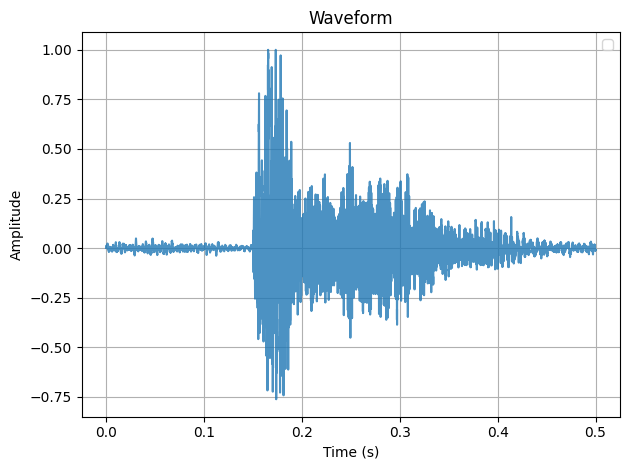

In [17]:
#filepath = df_test.sample(n=1)['path_file'].values[0]
waveform, sr = torchaudio.load(filepath)

# Flatten multi-channel (if stereo)
waveform = waveform.mean(dim=0)

# Normalize amplitude for visual comparability
waveform = waveform / waveform.abs().max()

t = torch.linspace(0, len(waveform) / sr, steps=len(waveform))
plt.plot(t, waveform, alpha=0.8)

plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()